# 第 1 章：人工智能概述

这一章我们先不急着写复杂代码。我们先建立一个最重要的直觉：

## AI 可以看成一个函数

```text
输出 = AI(输入)
```

你给它一段文字、一张图片、一段声音、一个任务，它经过模型处理后，给你一个结果。

这一章的目标是让你看懂：

1. AI 是什么。
2. AI 为什么像一个函数。
3. 一个 AI 系统里面有哪些部分。
4. 机器学习、深度学习、大模型、VLM、RAG、Agent 分别在架构里的什么位置。
5. 后面 8 次课我们要沿着哪条路线学习。

In [1]:
from IPython.display import HTML, display
import random
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def show(html):
    display(HTML(html))

show("""
<style>
.ai-course {font-family:-apple-system,BlinkMacSystemFont,"Segoe UI","PingFang SC","Microsoft YaHei",sans-serif; color:#172026;}
.ai-course * {box-sizing:border-box; letter-spacing:0;}
.hero {padding:28px 30px; border:1px solid #d9e1e7; border-radius:8px; background:#f8fafc; overflow:hidden;}
.hero h2 {margin:0 0 10px; font-size:34px; line-height:1.2;}
.hero p {font-size:18px; color:#475569; line-height:1.7; margin:8px 0;}
.kbd {display:inline-block; padding:4px 9px; border-radius:6px; background:#0f172a; color:#fff; font-family:ui-monospace, SFMono-Regular, Menlo, monospace;}
.grid {display:grid; grid-template-columns:repeat(3,minmax(0,1fr)); gap:14px; margin:18px 0;}
.grid.two {grid-template-columns:repeat(2,minmax(0,1fr));}
.card {border:1px solid #d9e1e7; border-radius:8px; background:white; padding:16px 18px; min-height:116px;}
.card h3 {font-size:20px; margin:0 0 8px;}
.card p,.card li {font-size:15px; line-height:1.65; color:#475569;}
.note {border-left:4px solid #2563eb; background:#eff6ff; color:#1e3a8a; padding:12px 14px; border-radius:0 8px 8px 0; margin:14px 0; line-height:1.7;}
.warn {border-left:4px solid #f97316; background:#fff7ed; color:#9a3412; padding:12px 14px; border-radius:0 8px 8px 0; margin:14px 0; line-height:1.7;}
.stage {height:340px; border:1px solid #d9e1e7; border-radius:8px; background:white; position:relative; overflow:hidden; margin:16px 0;}
.box {position:absolute; width:150px; min-height:78px; border:2px solid #d9e1e7; border-radius:8px; background:white; display:flex; flex-direction:column; align-items:center; justify-content:center; box-shadow:0 10px 24px rgba(15,23,42,.08); text-align:center; padding:8px;}
.box b {font-size:19px;}
.box small {font-size:13px; color:#64748b; margin-top:5px; line-height:1.35;}
.dot {position:absolute; width:18px; height:18px; border-radius:50%; left:95px; top:160px; background:#2563eb; box-shadow:0 0 0 8px rgba(37,99,235,.13); animation:move 5s ease-in-out infinite;}
.dot.green {background:#16a34a; box-shadow:0 0 0 8px rgba(22,163,74,.13); animation-delay:1.2s;}
.dot.orange {background:#f97316; box-shadow:0 0 0 8px rgba(249,115,22,.13); animation-delay:2.4s;}
@keyframes move {0%{transform:translateX(0); opacity:0} 10%{opacity:1} 35%{transform:translateX(220px)} 62%{transform:translateX(445px)} 88%{transform:translateX(665px); opacity:1} 100%{transform:translateX(760px); opacity:0}}
.pulse {animation:pulse 2.4s infinite;}
@keyframes pulse {0%,100%{box-shadow:0 0 0 0 rgba(37,99,235,.26)} 50%{box-shadow:0 0 0 15px rgba(37,99,235,0)}}
.fn {display:flex; align-items:center; justify-content:center; gap:14px; flex-wrap:wrap; margin:20px 0;}
.fnbox {border:2px solid #d9e1e7; border-radius:8px; padding:16px 20px; background:white; min-width:150px; text-align:center;}
.fnbox b {font-size:20px; display:block;}
.fnbox small {color:#64748b;}
.arrow {font-size:28px; color:#64748b;}
.layer {display:grid; grid-template-columns:180px 1fr; gap:12px; align-items:center; margin:12px 0;}
.layer .name {font-weight:800; font-size:18px;}
.bar {height:38px; background:#e5e7eb; border-radius:7px; overflow:hidden;}
.bar span {display:block; height:100%; line-height:38px; color:white; padding-left:14px; font-size:14px;}
.map {height:340px; border:1px solid #d9e1e7; border-radius:8px; background:white; position:relative; overflow:hidden;}
.circle {position:absolute; border:2px solid; border-radius:50%; display:flex; align-items:center; justify-content:center; text-align:center; font-weight:800; padding:8px;}
.course {display:grid; grid-template-columns:repeat(4,1fr); gap:12px; margin-top:16px;}
.lesson {border:1px solid #d9e1e7; border-radius:8px; padding:13px; background:white; min-height:118px;}
.lesson b {font-size:16px;}
.lesson p {font-size:13px; line-height:1.55; color:#64748b;}
.timeline {display:grid; grid-template-columns:repeat(5,1fr); gap:10px; margin:16px 0;}
.t {border:1px solid #d9e1e7; border-top:4px solid #2563eb; border-radius:8px; padding:12px; background:white; min-height:132px;}
.t b {font-size:16px;}
.t p {font-size:13px; color:#64748b; line-height:1.55;}
@media(max-width:900px){.grid,.grid.two,.course,.timeline{grid-template-columns:1fr}.stage{height:560px}.box{position:relative!important; left:auto!important; top:auto!important; margin:14px auto}.dot{display:none}.layer{grid-template-columns:1fr}.map{height:520px}}
</style>
<div class="ai-course hero">
  <h2>AI = 一个会学习的函数</h2>
  <p>普通函数是 <span class="kbd">y = f(x)</span>。AI 也可以先这样理解：<span class="kbd">结果 = AI(输入)</span>。</p>
  <p>区别在于：普通函数的规则通常由人写死，AI 的规则很多时候是从数据里学出来的。</p>
</div>
""")

## 1. 从函数开始理解 AI

你已经学过函数：

```text
y = f(x)
```

`x` 是输入，`f` 是处理规则，`y` 是输出。

AI 也可以这样看：

```text
输出 = AI模型(输入)
```

例如：

```text
“请总结这段文章” → AI模型 → 一段摘要
一张植物叶片照片 → AI模型 → 可能的病虫害类型
一个用户的浏览记录 → AI模型 → 推荐内容
一句语音 → AI模型 → 文字
```

In [2]:
show("""
<div class="ai-course">
  <div class="fn">
    <div class="fnbox"><b>输入 x</b><small>文字 / 图片 / 声音 / 数据</small></div>
    <div class="arrow">→</div>
    <div class="fnbox pulse" style="border-color:#2563eb"><b>AI 模型 f</b><small>把输入变成可计算信息</small></div>
    <div class="arrow">→</div>
    <div class="fnbox" style="border-color:#16a34a"><b>输出 y</b><small>判断 / 预测 / 生成 / 行动</small></div>
  </div>
  <div class="note">先把 AI 当成函数，你就不会被名词吓住。后面所有复杂系统，本质上都是围绕“输入、模型、输出、反馈”展开。</div>
</div>
""")

## 2. 普通函数和 AI 函数有什么区别

普通函数通常是人直接写规则。

AI 函数的关键是：**很多规则不是人手写的，而是模型从大量样本中学出来的。**

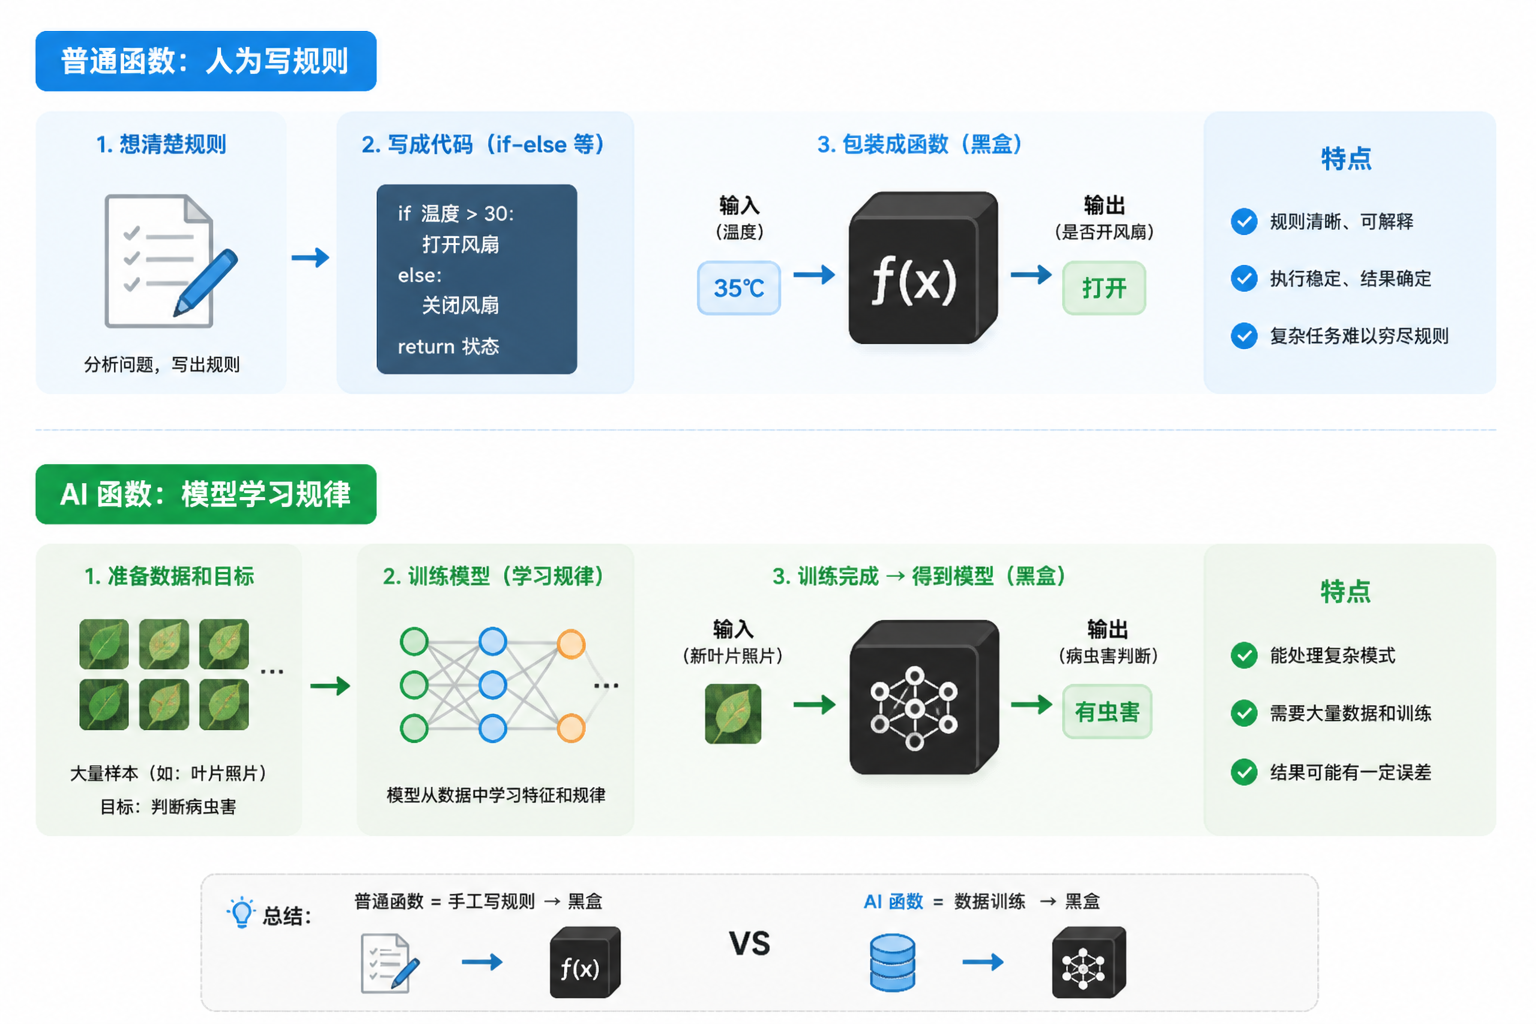

In [3]:
from pathlib import Path
from IPython.display import Image, display

image_path = Path("../src/8bc973c4-5923-41b4-960a-93e4c260f98d.png")
display(Image(filename=str(image_path), width=980))

## 3. 一个 AI 系统的完整架构

真实 AI 系统不只是一个模型。它通常包含下面这些部分：

```text
输入 → 数据处理 → 模型 → 输出 → 反馈
```

这条链路就是 AI 系统的骨架。

In [4]:
show("""
<div class="ai-course">
  <div style="max-width:980px; margin:16px auto; border:1px solid #d9e1e7; border-radius:8px; background:#fff; padding:18px;">
    <svg viewBox="0 0 980 430" width="100%" height="auto" role="img" aria-label="AI 系统完整架构：输入、数据处理、模型、输出、反馈">
      <defs>
        <filter id="shadow" x="-20%" y="-20%" width="140%" height="140%">
          <feDropShadow dx="0" dy="8" stdDeviation="8" flood-color="#0f172a" flood-opacity="0.12"/>
        </filter>
        <marker id="arrow-blue" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse">
          <path d="M 0 0 L 10 5 L 0 10 z" fill="#2563eb"/>
        </marker>
        <marker id="arrow-orange" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse">
          <path d="M 0 0 L 10 5 L 0 10 z" fill="#f97316"/>
        </marker>
      </defs>

      <text x="30" y="36" font-size="24" font-weight="800" fill="#172026">一个 AI 系统的完整架构</text>
      <text x="30" y="64" font-size="15" fill="#64748b">把 AI 看成函数：输入进入系统，经过处理和模型计算，产生输出；反馈再帮助系统改进。</text>

      <line x1="170" y1="175" x2="300" y2="175" stroke="#2563eb" stroke-width="4" marker-end="url(#arrow-blue)"/>
      <line x1="430" y1="175" x2="560" y2="175" stroke="#2563eb" stroke-width="4" marker-end="url(#arrow-blue)"/>
      <line x1="690" y1="175" x2="820" y2="175" stroke="#2563eb" stroke-width="4" marker-end="url(#arrow-blue)"/>

      <rect x="40" y="112" width="130" height="126" rx="10" fill="#ffffff" stroke="#cbd5e1" stroke-width="2" filter="url(#shadow)"/>
      <text x="105" y="155" text-anchor="middle" font-size="25" font-weight="800" fill="#172026">输入</text>
      <text x="105" y="184" text-anchor="middle" font-size="15" fill="#64748b">文本 / 图片</text>
      <text x="105" y="207" text-anchor="middle" font-size="15" fill="#64748b">声音 / 表格</text>

      <rect x="300" y="112" width="130" height="126" rx="10" fill="#f0f9ff" stroke="#0891b2" stroke-width="2" filter="url(#shadow)"/>
      <text x="365" y="155" text-anchor="middle" font-size="25" font-weight="800" fill="#172026">数据处理</text>
      <text x="365" y="184" text-anchor="middle" font-size="15" fill="#64748b">清洗 / 切分</text>
      <text x="365" y="207" text-anchor="middle" font-size="15" fill="#64748b">编码 / 向量化</text>

      <rect x="560" y="112" width="130" height="126" rx="10" fill="#eff6ff" stroke="#2563eb" stroke-width="3" filter="url(#shadow)"/>
      <text x="625" y="155" text-anchor="middle" font-size="25" font-weight="800" fill="#172026">模型</text>
      <text x="625" y="184" text-anchor="middle" font-size="15" fill="#64748b">学习到的函数</text>
      <text x="625" y="207" text-anchor="middle" font-size="15" fill="#64748b">f(x; 参数)</text>

      <rect x="820" y="112" width="130" height="126" rx="10" fill="#f0fdf4" stroke="#16a34a" stroke-width="2" filter="url(#shadow)"/>
      <text x="885" y="155" text-anchor="middle" font-size="25" font-weight="800" fill="#172026">输出</text>
      <text x="885" y="184" text-anchor="middle" font-size="15" fill="#64748b">分类 / 预测</text>
      <text x="885" y="207" text-anchor="middle" font-size="15" fill="#64748b">生成 / 行动</text>

      <rect x="430" y="294" width="160" height="92" rx="10" fill="#fff7ed" stroke="#f97316" stroke-width="2" filter="url(#shadow)"/>
      <text x="510" y="333" text-anchor="middle" font-size="24" font-weight="800" fill="#172026">反馈</text>
      <text x="510" y="361" text-anchor="middle" font-size="15" fill="#64748b">对不对 / 好不好</text>

      <path d="M 885 238 C 885 330, 650 340, 590 340" fill="none" stroke="#f97316" stroke-width="4" marker-end="url(#arrow-orange)"/>
      <path d="M 430 340 C 300 340, 365 260, 365 238" fill="none" stroke="#f97316" stroke-width="4" marker-end="url(#arrow-orange)"/>
      <text x="690" y="320" font-size="15" fill="#f97316" font-weight="700">输出结果会反过来改进模型和数据处理</text>

      <circle cx="235" cy="175" r="9" fill="#2563eb">
        <animate attributeName="cx" values="185;285" dur="1.7s" repeatCount="indefinite"/>
        <animate attributeName="opacity" values="0;1;1;0" dur="1.7s" repeatCount="indefinite"/>
      </circle>
      <circle cx="495" cy="175" r="9" fill="#0891b2">
        <animate attributeName="cx" values="445;545" dur="1.7s" begin="0.35s" repeatCount="indefinite"/>
        <animate attributeName="opacity" values="0;1;1;0" dur="1.7s" begin="0.35s" repeatCount="indefinite"/>
      </circle>
      <circle cx="755" cy="175" r="9" fill="#16a34a">
        <animate attributeName="cx" values="705;805" dur="1.7s" begin="0.7s" repeatCount="indefinite"/>
        <animate attributeName="opacity" values="0;1;1;0" dur="1.7s" begin="0.7s" repeatCount="indefinite"/>
      </circle>
    </svg>
  </div>
</div>
""")

你可以把每一部分想成工厂里的不同环节：

- **输入**：原材料进来。
- **数据处理**：把原材料整理成机器能吃的格式。
- **模型**：核心加工机器。
- **输出**：成品出来。
- **反馈**：检查成品质量，用来改进系统。

## 4. 模型到底在“学”什么

模型学习的不是一句神秘咒语，而是参数。

可以先这样理解：

```text
输出 = 模型(输入, 参数)
```

训练的过程，就是不断调整参数，让输出越来越接近正确答案。

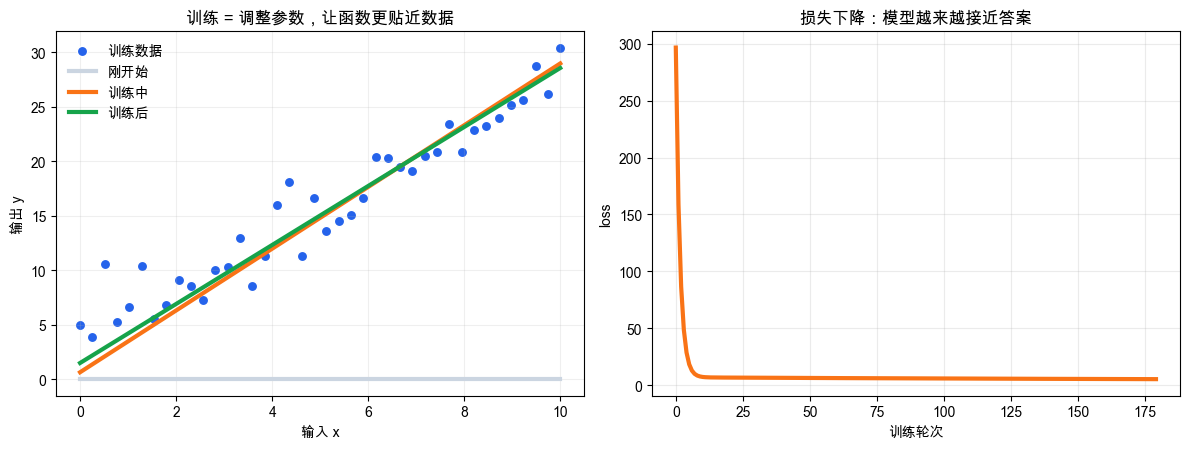

训练后模型大约学到：输出 = 2.71 × 输入 + 1.49


In [5]:
np.random.seed(5)

x = np.linspace(0, 10, 40)
y = 2.3 * x + 4 + np.random.normal(0, 2.2, size=len(x))

w, b = 0.0, 0.0
lr = 0.004
history = []
for step in range(180):
    pred = w * x + b
    loss = ((pred - y) ** 2).mean()
    history.append((w, b, loss))
    dw = (2 * x * (pred - y)).mean()
    db = (2 * (pred - y)).mean()
    w -= lr * dw
    b -= lr * db

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].scatter(x, y, color='#2563eb', s=55, edgecolor='white', label='训练数据')
for idx, color, label in [(0, '#cbd5e1', '刚开始'), (30, '#f97316', '训练中'), (179, '#16a34a', '训练后')]:
    ww, bb, _ = history[idx]
    axes[0].plot(x, ww*x+bb, color=color, linewidth=3, label=label)
axes[0].set_title('训练 = 调整参数，让函数更贴近数据')
axes[0].set_xlabel('输入 x')
axes[0].set_ylabel('输出 y')
axes[0].legend(frameon=False)
axes[0].grid(alpha=.2)

axes[1].plot([h[2] for h in history], color='#f97316', linewidth=3)
axes[1].set_title('损失下降：模型越来越接近答案')
axes[1].set_xlabel('训练轮次')
axes[1].set_ylabel('loss')
axes[1].grid(alpha=.25)
plt.tight_layout()
plt.show()

print(f"训练后模型大约学到：输出 = {w:.2f} × 输入 + {b:.2f}")

这个小实验虽然简单，但它已经包含了 AI 训练的核心：

1. 有输入和正确输出。
2. 模型先随便猜。
3. 计算猜得有多差，这叫损失。
4. 调整参数。
5. 重复很多次。

神经网络、大模型训练也遵循这个大方向，只是函数更复杂、参数更多、数据更大。

## 5. AI、机器学习、深度学习、大模型是什么关系

很多同学一开始会把这些词混在一起。它们不是并列关系，而是包含关系。

In [6]:
show("""
<div class="ai-course">
  <div class="map">
    <div class="circle" style="left:48px; top:34px; width:270px; height:270px; border-color:#2563eb; background:#eff6ff; color:#1d4ed8;">AI<br><span style="font-size:13px;font-weight:500;">让机器表现出智能</span></div>
    <div class="circle" style="left:142px; top:76px; width:218px; height:218px; border-color:#16a34a; background:#f0fdf4; color:#15803d;">机器学习<br><span style="font-size:13px;font-weight:500;">从数据中学习函数</span></div>
    <div class="circle" style="left:250px; top:110px; width:170px; height:170px; border-color:#f97316; background:#fff7ed; color:#c2410c;">深度学习<br><span style="font-size:13px;font-weight:500;">多层神经网络</span></div>
    <div class="circle" style="left:356px; top:142px; width:128px; height:128px; border-color:#7c3aed; background:#f5f3ff; color:#6d28d9;">大模型<br><span style="font-size:12px;font-weight:500;">LLM / VLM</span></div>
    <div style="position:absolute; right:34px; top:62px; width:310px; font-size:15px; color:#475569; line-height:1.8;">
      <b style="font-size:20px; color:#172026;">从大到小看</b><br>
      AI 是目标。机器学习是方法。深度学习是机器学习的一条强路线。大模型是深度学习扩展到超大规模后的结果。
    </div>
  </div>
</div>
""")

一句话记忆：

```text
AI 是大目标，机器学习是让机器从数据中学习，深度学习是用神经网络学习，大模型是神经网络做大之后的代表。
```

## 6. 为什么今天的大模型这么重要

大模型的特殊之处在于：它不只会做一个任务，而是可以通过自然语言适配很多任务。

过去很多 AI 系统像“专用工具”：一个模型做一个任务。  
大模型更像“通用接口”：你用自然语言告诉它要做什么。

In [7]:
show("""
<div class="ai-course grid two">
  <div class="card">
    <h3>传统专用模型</h3>
    <p>垃圾邮件分类模型：只判断邮件。</p>
    <p>手写数字模型：只识别数字。</p>
    <p>人脸检测模型：只找人脸。</p>
  </div>
  <div class="card">
    <h3>大模型</h3>
    <p>可以总结文章、写代码、翻译、解释图片、规划任务。</p>
    <p>不是因为它有魔法，而是它在大规模数据上学到了更通用的表示。</p>
  </div>
</div>
""")

## 7. LLM、VLM、RAG、Agent 在架构里的位置

现在我们把常见的新词放回“AI 函数”的架构中。

In [8]:
show("""
<div class="ai-course">
  <div class="layer"><div class="name">LLM</div><div class="bar"><span style="width:72%; background:#2563eb;">语言模型：输入文字，输出文字。比如问答、总结、写代码。</span></div></div>
  <div class="layer"><div class="name">VLM</div><div class="bar"><span style="width:80%; background:#0891b2;">视觉语言模型：输入图片 + 文字，输出理解结果。</span></div></div>
  <div class="layer"><div class="name">RAG</div><div class="bar"><span style="width:88%; background:#16a34a;">检索增强生成：模型回答前先查资料，让回答有依据。</span></div></div>
  <div class="layer"><div class="name">Agent</div><div class="bar"><span style="width:96%; background:#f97316;">智能体：模型会规划步骤，并调用工具完成任务。</span></div></div>
  <div class="note">可以这样记：LLM 会读写，VLM 会看图，RAG 会查资料，Agent 会用工具办事。</div>
</div>
""")

## 8. 生成式 AI 的直觉：不断预测下一个符号

语言模型的一个核心思想是：根据前面的上下文，预测下一个 token。

为了直观理解，我们做一个极小的字符生成实验。它不是大模型，但能展示生成的基本味道。

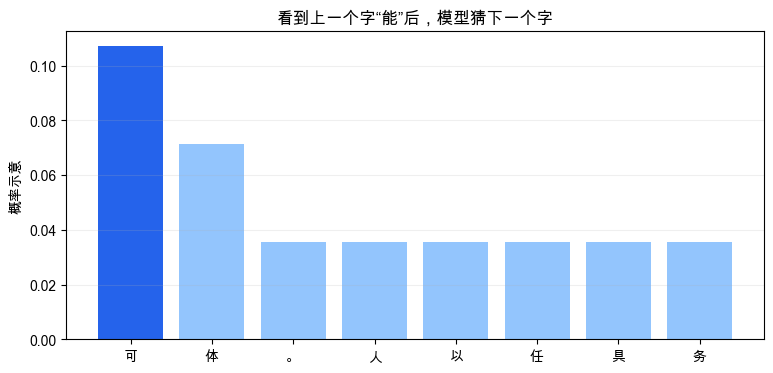

人工智能具人完体人完言用生具成务任以务语解能


In [9]:
text = "人工智能可以理解语言。人工智能可以生成文本。大模型可以调用工具。智能体可以完成任务。"
chars = sorted(set(text))
counts = {c: {d: 1 for d in chars} for c in chars}
for a, b in zip(text, text[1:]):
    counts[a][b] += 1

def next_probs(ch):
    row = counts.get(ch, {d: 1 for d in chars})
    total = sum(row.values())
    return {k: v / total for k, v in row.items()}

context = '能'
probs = next_probs(context)
top = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)[:8]

fig, ax = plt.subplots(figsize=(9, 4))
labels = [k for k, _ in top]
vals = [v for _, v in top]
ax.bar(labels, vals, color=['#2563eb'] + ['#93c5fd'] * (len(vals) - 1))
ax.set_title(f'看到上一个字“{context}”后，模型猜下一个字')
ax.set_ylabel('概率示意')
ax.grid(axis='y', alpha=.2)
plt.show()

random.seed(4)
out = '人工智能'
for _ in range(18):
    p = next_probs(out[-1])
    out += random.choices(list(p.keys()), weights=list(p.values()), k=1)[0]
print(out)

你会发现这个小模型生成得不一定通顺。原因很简单：它只看上一个字，太弱了。

真正的大模型会看很长的上下文，并用神经网络学习更深的关系。所以它能生成更连贯、更有逻辑的回答。

但最底层的直觉仍然很重要：

```text
根据上下文 → 预测下一个 token → 接着再预测下一个 token → 形成完整输出
```

## 9. AI 系统为什么需要数据、算力、算法和工程

一个 AI 系统能不能做好，不只看模型名字。至少要看四件事。

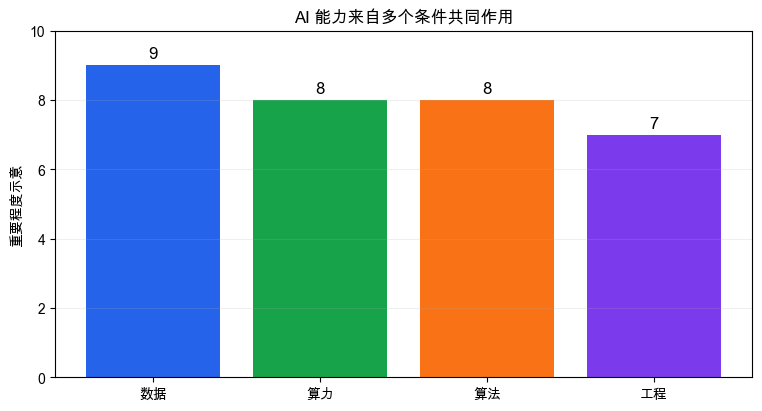

In [10]:
factors = ['数据', '算力', '算法', '工程']
values = [9, 8, 8, 7]
colors = ['#2563eb', '#16a34a', '#f97316', '#7c3aed']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(factors, values, color=colors)
ax.set_ylim(0, 10)
ax.set_title('AI 能力来自多个条件共同作用')
ax.set_ylabel('重要程度示意')
for i, v in enumerate(values):
    ax.text(i, v + 0.2, str(v), ha='center', fontsize=12)
ax.grid(axis='y', alpha=.2)
plt.show()

四个部分可以这样理解：

- **数据**：模型从哪里学习。
- **算力**：模型有没有足够计算资源训练和运行。
- **算法**：用什么方法学习规律。
- **工程**：怎么把模型做成稳定可用的系统。

课堂和真实项目里，工程经常和模型同样重要。

## 10. 本课程 8 次课的学习路线

接下来我们不是零散地学名词，而是沿着 AI 函数一步步拆开。

In [11]:
show("""
<div class="ai-course course">
  <div class="lesson"><b>1. 人工智能概述</b><p>把 AI 看成函数，理解输入、模型、输出和反馈。</p></div>
  <div class="lesson"><b>2. 机器学习基础</b><p>数据、特征、训练、损失、泛化。</p></div>
  <div class="lesson"><b>3. 神经网络基础</b><p>神经元、计算图、梯度、反向传播。</p></div>
  <div class="lesson"><b>4. 深度学习模型</b><p>CNN、RNN、注意力、Transformer。</p></div>
  <div class="lesson"><b>5. AI 语言与工具</b><p>Python、Notebook、Prompt、API、向量工具。</p></div>
  <div class="lesson"><b>6. 计算机视觉</b><p>图像分类、CNN、目标检测、VLM。</p></div>
  <div class="lesson"><b>7. 自然语言处理</b><p>语言模型、token、embedding、搜索、对话。</p></div>
  <div class="lesson"><b>8. 大模型、VLM、RAG 与 Agent</b><p>把模型接入知识库和工具，形成应用系统。</p></div>
</div>
""")

## 11. 本章小结

这一章你只需要牢牢记住一件事：

```text
AI 是一个从输入到输出的函数，只不过这个函数很多时候是从数据中学出来的。
```

围绕这个函数，有五个关键部分：

1. 输入：文字、图像、声音、结构化数据。
2. 数据处理：把输入变成机器能计算的形式。
3. 模型：学习到的函数。
4. 输出：判断、预测、生成、行动。
5. 反馈：评价结果，并帮助系统改进。

后面的课程就是不断拆解这个函数：它怎么学习，怎么用神经网络表达，怎么处理图像和语言，怎么连接知识库，怎么调用工具完成任务。

## 课后思考

1. 如果把 ChatGPT 看成一个函数，它的输入和输出分别是什么？
2. 如果把“识别一张叶片是否有病虫害”看成一个 AI 函数，需要哪些输入数据？输出应该是什么？
3. 普通程序和 AI 模型最大的区别是什么？
4. 为什么大模型需要 RAG？
5. Agent 比普通聊天机器人多了什么能力？